In [39]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision.models as models
from torchvision import transforms

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

Выбранный датасет: Digits из sklearn

In [10]:
digits = load_digits()

X = digits.images
y = digits.target

print("Размер X:", X.shape)
print("Размер y:", y.shape)
print("Количество классов:", len(set(y)))

Размер X: (1797, 8, 8)
Размер y: (1797,)
Количество классов: 10


Разделение на train и test

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (1437, 8, 8)
Test: (360, 8, 8)


Преобразование изображений: В digits значения пикселей находятся в диапазоне 0..16. Переводим их в 0..255 для дальнейшего преобразования в изображение.

In [12]:
X_train = (X_train / 16.0 * 255).astype("uint8")
X_test = (X_test / 16.0 * 255).astype("uint8")


transform = transforms.Compose([
    transforms.ToPILImage(),

    transforms.Resize((224, 224)),

    transforms.Grayscale(num_output_channels=3),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

Создание датасета

In [13]:
class DigitsDataset(Dataset):

    def __init__(self, images, labels, transform):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        image = self.images[index]
        label = self.labels[index]

        image = self.transform(image)

        return image, label


train_dataset = DigitsDataset(
    X_train,
    y_train,
    transform
)

test_dataset = DigitsDataset(
    X_test,
    y_test,
    transform
)


DataLoader

In [14]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

Выбор устройства

In [15]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Устройство:", device)

Устройство: cpu


Выбранная предобученная архитектура: ResNet-18

In [16]:
model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

Заморозка весов базовой сети

In [17]:
for param in model.parameters():
    param.requires_grad = False

Замена последнего слоя

In [18]:
model.fc = nn.Linear(
    model.fc.in_features,
    10
)

model = model.to(device)

Функция потерь и оптимизатор

In [19]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

Обучение

In [21]:
num_epochs = 5

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    average_loss = running_loss / len(train_loader)

    print(
        f"Epoch {epoch + 1}/{num_epochs}, "
        f"Loss: {average_loss:.4f}"
    )


Epoch 1/5, Loss: 1.6519
Epoch 2/5, Loss: 1.0007
Epoch 3/5, Loss: 0.6969
Epoch 4/5, Loss: 0.5432
Epoch 5/5, Loss: 0.4352


Получение предсказаний из тестовой выборки

In [22]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        y_true.extend(labels.numpy())
        y_pred.extend(
            predictions.cpu().numpy()
        )

Accuracy

In [23]:
accuracy = accuracy_score(
    y_true,
    y_pred
)

print()
print(f"Accuracy: {accuracy:.4f}")


Accuracy: 0.9444


Confusion matrix


Confusion Matrix:
[[35  0  0  0  0  0  0  0  0  1]
 [ 0 34  2  0  0  0  0  0  0  0]
 [ 0  0 32  0  0  0  0  0  1  2]
 [ 0  0  1 36  0  0  0  0  0  0]
 [ 0  0  0  0 34  1  0  0  0  1]
 [ 0  0  0  0  0 37  0  0  0  0]
 [ 0  0  0  0  0  2 34  0  0  0]
 [ 0  0  0  0  0  1  0 35  0  0]
 [ 0  1  0  1  0  0  0  1 31  1]
 [ 0  1  0  0  0  1  0  1  1 32]]


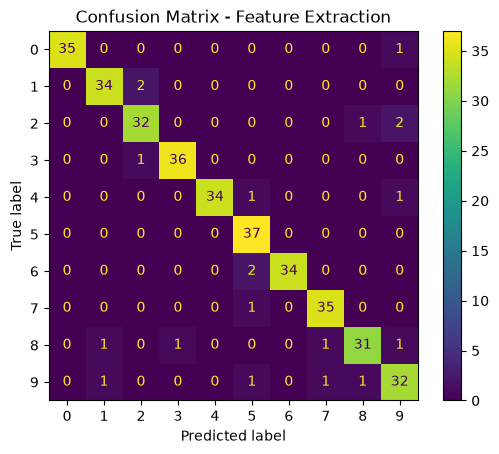

In [25]:
cm = confusion_matrix(
    y_true,
    y_pred
)

print()
print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=range(10)
)

disp.plot()

plt.title("Confusion Matrix - Feature Extraction")
plt.show()

Новая модель ResNet-18 и заморозка всех слоёв кроме верхнего

In [28]:
model_ft = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

for param in model_ft.parameters():
    param.requires_grad = False

for param in model_ft.layer4.parameters():
    param.requires_grad = True

Замена последнего слоя

In [29]:
model_ft.fc = nn.Linear(
    model_ft.fc.in_features,
    10
)

model_ft = model_ft.to(device)

Функция потерь и оптимизатор

In [32]:
criterion_ft = nn.CrossEntropyLoss()

optimizer_ft = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_ft.parameters()),
    lr=0.00001
)

Обучение Fine-Tuning

In [33]:
num_epochs = 5

for epoch in range(num_epochs):

    model_ft.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer_ft.zero_grad()

        outputs = model_ft(images)

        loss = criterion_ft(outputs, labels)

        loss.backward()

        optimizer_ft.step()

        running_loss += loss.item()

    average_loss = running_loss / len(train_loader)

    print(
        f"Epoch {epoch + 1}/{num_epochs}, "
        f"Loss: {average_loss:.4f}"
    )

Epoch 1/5, Loss: 1.9942
Epoch 2/5, Loss: 1.2314
Epoch 3/5, Loss: 0.7873
Epoch 4/5, Loss: 0.5335
Epoch 5/5, Loss: 0.3727


Получение предсказаний

In [34]:
model_ft.eval()

y_true_ft = []
y_pred_ft = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model_ft(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        y_true_ft.extend(labels.numpy())
        y_pred_ft.extend(
            predictions.cpu().numpy()
        )

Accuracy

In [35]:
accuracy_ft = accuracy_score(
    y_true_ft,
    y_pred_ft
)

print()
print(f"Accuracy Fine-tuning: {accuracy_ft:.4f}")


Accuracy Fine-tuning: 0.9667


Confusion Matrix


Confusion Matrix - Fine-tuning:
[[35  0  0  0  0  0  0  0  1  0]
 [ 0 36  0  0  0  0  0  0  0  0]
 [ 0  0 35  0  0  0  0  0  0  0]
 [ 0  0  0 37  0  0  0  0  0  0]
 [ 0  0  0  0 36  0  0  0  0  0]
 [ 0  0  0  0  0 37  0  0  0  0]
 [ 0  1  0  0  0  0 34  0  1  0]
 [ 0  0  0  0  0  0  0 36  0  0]
 [ 0  3  0  0  0  0  0  0 32  0]
 [ 0  0  0  0  0  1  0  2  3 30]]


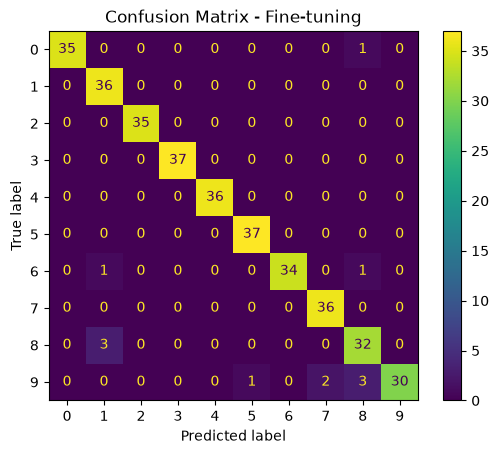

In [37]:
cm_ft = confusion_matrix(
    y_true_ft,
    y_pred_ft
)

print()
print("Confusion Matrix - Fine-tuning:")
print(cm_ft)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_ft,
    display_labels=range(10)
)

disp.plot()

plt.title("Confusion Matrix - Fine-tuning")
plt.show()

Метрики Feature Extraction

In [40]:
accuracy_fe = accuracy_score(
    y_true,
    y_pred
)

precision_fe = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall_fe = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

print("Feature Extraction:")
print(f"Accuracy:  {accuracy_fe:.4f}")
print(f"Precision: {precision_fe:.4f}")
print(f"Recall:    {recall_fe:.4f}")

Feature Extraction:
Accuracy:  0.9444
Precision: 0.9463
Recall:    0.9444


Метрики Fine-tuning

In [41]:
accuracy_ft = accuracy_score(
    y_true_ft,
    y_pred_ft
)

precision_ft = precision_score(
    y_true_ft,
    y_pred_ft,
    average="weighted"
)

recall_ft = recall_score(
    y_true_ft,
    y_pred_ft,
    average="weighted"
)

print("Fine-tuning:")
print(f"Accuracy:  {accuracy_ft:.4f}")
print(f"Precision: {precision_ft:.4f}")
print(f"Recall:    {recall_ft:.4f}")

Fine-tuning:
Accuracy:  0.9667
Precision: 0.9689
Recall:    0.9667


Сравнение

In [42]:
print()
print("Сравнение методов:")
print()

print(f"{'Метрика':<12} {'Feature Extraction':<20} {'Fine-tuning':<20}")
print("-" * 52)

print(
    f"{'Accuracy':<12} "
    f"{accuracy_fe:<20.4f} "
    f"{accuracy_ft:<20.4f}"
)

print(
    f"{'Precision':<12} "
    f"{precision_fe:<20.4f} "
    f"{precision_ft:<20.4f}"
)

print(
    f"{'Recall':<12} "
    f"{recall_fe:<20.4f} "
    f"{recall_ft:<20.4f}"
)


Сравнение методов:

Метрика      Feature Extraction   Fine-tuning         
----------------------------------------------------
Accuracy     0.9444               0.9667              
Precision    0.9463               0.9689              
Recall       0.9444               0.9667              
